### plan node 점검 

In [1]:
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("utils"), "..")))
from module.utils import *
from module.prompt import *
from module.custom_model import *
from module.base_model import *
from module.tools import *

start_langsmith("final_music")
from typing import TypedDict, Annotated, List, Literal, Tuple
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks

LangSmith 추적을 시작합니다.
[프로젝트명]
final_music


In [19]:
class State(TypedDict):
    question: Annotated[str, "user input question"]  # 사용자 질의 or requeustion 질의
    plan: Annotated[list[str], "get plan_node"]  # llm 생성한 작업 계획서
    messages: Annotated[list, add_messages]  # 작업 수행 후 얻은 데이터
    current_steps: Annotated[str, "current step"]  # 현재 단계에서 수행한 결과
    past_steps: Annotated[list, add_messages]  # 현재 단계에서 수행한 결과
    answer: Annotated[str, " output final answer"]  # 최종 답변 출력
    human_feedback: bool = False
    db_query: Annotated[str, "db_query"]  # 현재 단계에서 수행한 결과
    next_agent: Annotated[str, " use agent"]
    summary: Annotated[str, " 요약"]

In [ ]:
def plan_node(state: State) -> State:
    llm = get_gpt()
    prompt = get_prompt_music_planner()
    chain = prompt | llm.with_structured_output(PlanListModel)
    response = chain.invoke({"messages": [state["question"]]})
    return State({"plan": response.steps,'messages':response.steps})


def next_agent_node(state: State) -> State:
    plan = state.get("plan", [state["question"]])
    next_task = plan[0]
    prompt = get_prompt_routing_node()
    llm = get_gpt()
    chain = prompt | llm.with_structured_output(RouteModel)
    result = chain.invoke({"next_task": next_task})
    response = f"실행 계획 : {next_task} \n 사용 도구 : {result.datasource}"
    return State(
        {
            "current_steps": next_task,
            "messages": AIMessage(content=response),
            "next_agent": result.datasource,
        }
    )


def final_node(state: State) -> State:
    llm = get_gemini()
    chain = get_prompt_final() | llm
    result = chain.invoke(
        {
            "current_steps": state["current_steps"],
            "next_agent": state["next_agent"],
            "plan": state.get('plan'),
        }
    )
    return State({"messages": [result], "answer": result.content})

In [45]:
state_graph = StateGraph(State)
state_graph.add_node("plan_node", plan_node)
state_graph.add_node("next_agent_node", next_agent_node)
state_graph.add_node("final_node", final_node)


state_graph.add_edge(START, "plan_node")
state_graph.add_edge('plan_node', "next_agent_node")
state_graph.add_edge('next_agent_node', "final_node")
state_graph.add_edge("final_node", END)

cp = get_check_pointer()
graph = state_graph.compile(checkpointer=cp)

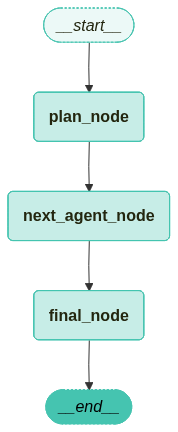

In [46]:
visualize_graph(graph)

In [50]:
config = get_runnable_config(recursion_limit=20, thread_id=get_random_uuid())

query = "안녕 내이름은 Kara Nielsen이야"
inputs = {"question": query,'messages':query}
response = graph.invoke(input=inputs, config=config, stream_mode="values")
print(response)

{'question': '안녕 내이름은 Kara Nielsen이야', 'plan': ['안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?'], 'messages': [HumanMessage(content='안녕 내이름은 Kara Nielsen이야', additional_kwargs={}, response_metadata={}, id='f562cb04-8142-415f-8804-1e6ad583ee19'), HumanMessage(content='안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='308ec3bc-18b3-4015-becd-25c09f250034'), AIMessage(content='실행 계획 : 안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요? \n 사용 도구 : conversation_agent', additional_kwargs={}, response_metadata={}, id='f0fdf4e6-638a-4a3a-bbee-8d6d26f0bef1'), AIMessage(content='안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--c103a060-9634-4402-92b0-52572a92762f-0', usage_metadata={'input_tokens': 201, 'output_tokens': 12, 'total_tokens': 213, 'input_token_details': {'cache_read': 0}})], 'current_steps': '안녕

In [51]:
query = " 내 FavoriteMusic 어떤 곡잇는지 알려줘? "
inputs = {"question": query}
response = graph.invoke(input=inputs, config=config, stream_mode="values")
print(response)

{'question': ' 내 FavoriteMusic 어떤 곡잇는지 알려줘? ', 'plan': ['내 FavoriteMusic에 어떤 곡이 있는지 알려줘?'], 'messages': [HumanMessage(content='안녕 내이름은 Kara Nielsen이야', additional_kwargs={}, response_metadata={}, id='f562cb04-8142-415f-8804-1e6ad583ee19'), HumanMessage(content='안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='308ec3bc-18b3-4015-becd-25c09f250034'), AIMessage(content='실행 계획 : 안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요? \n 사용 도구 : conversation_agent', additional_kwargs={}, response_metadata={}, id='f0fdf4e6-638a-4a3a-bbee-8d6d26f0bef1'), AIMessage(content='안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--c103a060-9634-4402-92b0-52572a92762f-0', usage_metadata={'input_tokens': 201, 'output_tokens': 12, 'total_tokens': 213, 'input_token_details': {'cache_read': 0}}), HumanMessage(co

In [52]:
query = " 아니다 오늘 서울 날씨 알려줘 "
inputs = {"question": query}
response = graph.invoke(input=inputs, config=config, stream_mode="values")
print(response)

{'question': ' 아니다 오늘 서울 날씨 알려줘 ', 'plan': ['오늘 서울의 날씨를 확인한다.', '서울의 현재 기온, 강수 확률, 미세먼지 상태를 알려준다.'], 'messages': [HumanMessage(content='안녕 내이름은 Kara Nielsen이야', additional_kwargs={}, response_metadata={}, id='f562cb04-8142-415f-8804-1e6ad583ee19'), HumanMessage(content='안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='308ec3bc-18b3-4015-becd-25c09f250034'), AIMessage(content='실행 계획 : 안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요? \n 사용 도구 : conversation_agent', additional_kwargs={}, response_metadata={}, id='f0fdf4e6-638a-4a3a-bbee-8d6d26f0bef1'), AIMessage(content='안녕하세요, Kara Nielsen님! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--c103a060-9634-4402-92b0-52572a92762f-0', usage_metadata={'input_tokens': 201, 'output_tokens': 12, 'total_tokens': 213, 'input_token_details': {'cache_read': 0}}), HumanM